In [133]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fractions import Fraction
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator, ScalarFormatter

def plot_ratio_line_subplots_beautiful(
    df: pd.DataFrame,
    remove_p = (0.6,),          # omit p=0.6 by default; pass () to keep all
    use_log_y: bool = True,     # set False for linear y
    bar_width: float = 0.06,    # wider bars on the ratio line
    jitter: float = 0.009,      # small horizontal separation between schemes
    figsize_per_p: float = 6.5, # width (inches) per subplot
    annotate_best: bool = True, # outline + value label for best-at-ratio
    suptitle: str = "Scheme Comparison by Ratio",
    output_path: str = None
):
    def to_fraction_str(numer, denom):
        try:
            f = Fraction(int(numer), int(denom))
            return f"{f.numerator}/{f.denominator}"
        except Exception:
            return f"{numer}/{denom}"

    def parse_row(name):
        s = str(name).strip()

        m_agg = re.search(r'agg[_\- ]?mac[_\- ]?(\d+)', s, flags=re.IGNORECASE)
        if m_agg:
            n = int(m_agg.group(1))
            return "AGG_MAC", f"1/{n}", 1.0/n

        m_frac = re.search(r'(\d+)\s*/\s*(\d+)', s)
        if m_frac:
            a, b = int(m_frac.group(1)), int(m_frac.group(2))
            head = s[:m_frac.start()]
            head = re.sub(r'[_\-\s]+$', '', head)
            m_head = re.search(r'([A-Za-z0-9\-\(\)_]+)$', head)
            scheme = m_head.group(1) if m_head else head
            return scheme, to_fraction_str(a, b), (a / b if b else np.nan)

        if re.search(r'\bwhip', s, flags=re.IGNORECASE):
            return s, "1/1", 1.0
        if re.search(r'\btrad(itional)?\b', s, flags=re.IGNORECASE):
            return "Traditional", "1/1", 1.0

        if "golomb" in s.lower():
            return "Golomb-SP_MAC", "1/1", 1.0
        
        if s.lower() == "g-sidon_2":
            return "Sidon-SP_MAC", "1/1", 1.0

        scheme = re.split(r'[_\-]', s)[0] if s else s
        return scheme, "1/1", 1.0

    need = {"name","res","p"}
    if not need.issubset(df.columns):
        missing = need - set(df.columns)
        raise ValueError(f"df must contain columns {need}, missing: {missing}")

    data = df.copy()
    parsed = data["name"].apply(parse_row)
    data[["scheme","ratio_str","ratio_num"]] = pd.DataFrame(parsed.tolist(), index=data.index)

    if remove_p:
        data = data[~data["p"].isin(remove_p)]
    if data.empty:
        raise ValueError("No data left after filtering 'p'.")

    agg = (
        data.groupby(["p","ratio_num","ratio_str","scheme"], dropna=False)["res"]
            .mean()
            .reset_index()
    )

    p_values = sorted(agg["p"].unique(), reverse=1)
    schemes = sorted(agg["scheme"].unique(), key=lambda s: (not str(s).startswith("Whip"), str(s)))

    # Gentle palette & hatches (tweak if you want different colors)
    colors_for = {
        "OptiMAC": "tab:red",
        "AGG_MAC": "tab:green",
        "Traditional": "black",
        "Sidon-SP_MAC": "tab:purple",
        "Golomb-SP_MAC": "chocolate",
    }
    hatch_for = {"Whip_2":"//", "Whip_3":"xx", "Whip_4":"..", "Whip_5":"++"}

    # Minimalist style
    plt.rcParams.update({
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.titlesize": 17, "axes.labelsize": 17,
        "xtick.labelsize": 17, "ytick.labelsize": 17,
        "legend.fontsize": 17,
    })

    ncols = len(p_values)
    fig, axes = plt.subplots(1, ncols, figsize=(figsize_per_p*ncols, 5.6), sharey=True, dpi = 150)
    if ncols == 1:
        axes = [axes]

    for ax in axes:
        ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=0.6)
        ax.tick_params(axis='x', which='both', length=0)  # cleaner x-axis

    for ax, pval in zip(axes, p_values):
        sub = agg[agg["p"] == pval].copy()
        ratios_sorted = sorted(np.round(np.linspace(0, 1.05, 4)))
        ax.set_xlim(-0.00, 1.11)

        n_series = len(schemes)
        offsets = {s: (i - (n_series - 1)/2) * jitter for i, s in enumerate(schemes)}

        # draw bars
        drawn = {}  # (ratio_num) -> list of (bar, val, scheme)
        for scheme in schemes:
            ssub = sub[sub["scheme"] == scheme]
            if ssub.empty: 
                continue
            xs = ssub["ratio_num"].values + np.array([offsets[scheme]] * len(ssub))
            ys = ssub["res"].values

            bars = ax.bar(
                xs, ys,
                width=bar_width,
                align="center",
                label=scheme,
                color=colors_for.get(scheme, None),
                edgecolor="white",
                linewidth=0.5,
                alpha=0.9,
            )
            if str(scheme).startswith("Whip"):
                for b in bars: b.set_hatch(hatch_for.get(scheme, ""))

            # track for best annotation
            for x, y, b in zip(xs, ys, bars):
                drawn.setdefault(round(float(x), 6), []).append((b, y, scheme))

        # annotate best per ratio
        if annotate_best:
            for xkey, items in drawn.items():
                # best = max y
                b, y, scheme = max(items, key=lambda t: t[1])
                # outline
                b.set_linewidth(1.2)
                b.set_edgecolor("#222222")
                # label (avoid clutter for very small bars)
                # if y > 0:
                #     ax.annotate(f"{y:.3g}",
                #                 xy=(b.get_x() + b.get_width()/2, y),
                #                 xytext=(0, 4),
                #                 textcoords="offset points",
                #                 ha="center", va="bottom",
                #                 fontsize=9, color="#222222")

        # axes polish
        ax.set_title(f"attack rate = {np.round(1-pval,1)}")
        if use_log_y:
            ax.set_yscale("log")
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
            ax.yaxis.set_minor_locator(MaxNLocator(nbins=12))
            ax.yaxis.set_major_formatter(ScalarFormatter())
            ax.tick_params(axis='y', which='minor', length=0)
        else:
            ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

        # fraction tick labels in numeric order
        frac_map = (
            sub.sort_values(["ratio_num","ratio_str"])
               .groupby("ratio_num")["ratio_str"]
               .first()
               .to_dict()
        )
        ax.set_xticks(ratios_sorted)
        # thin out labels if too many
        # labels = [frac_map[r] for r in ratios_sorted]
        # if len(labels) > 18:
        #     # keep every 2nd label for readability
        #     labels = [lab if i % 2 == 0 else "" for i, lab in enumerate(labels)]
        # ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_xlabel("TMR")

    axes[0].set_ylabel("Goodput (%)")

    # unified legend
    legend_handles, seen = [], set()
    for scheme in schemes:
        patch = Patch(
            facecolor=colors_for.get(scheme, None),
            edgecolor="white",
            hatch=hatch_for.get(scheme, ""),
            label=scheme
        )
        if scheme not in seen:
            legend_handles.append(patch); seen.add(scheme)

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=min(len(schemes), 5),
        frameon=False,
        fontsize= 15,
        # font = 13
        bbox_to_anchor=(0.5, 1.156)
    )
    if suptitle:
        fig.suptitle(suptitle, y=1.09, fontsize=15, fontweight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if output_path:
        plt.savefig(output_path, dpi=180, bbox_inches="tight")
        plt.close()
    else:
        plt.show()


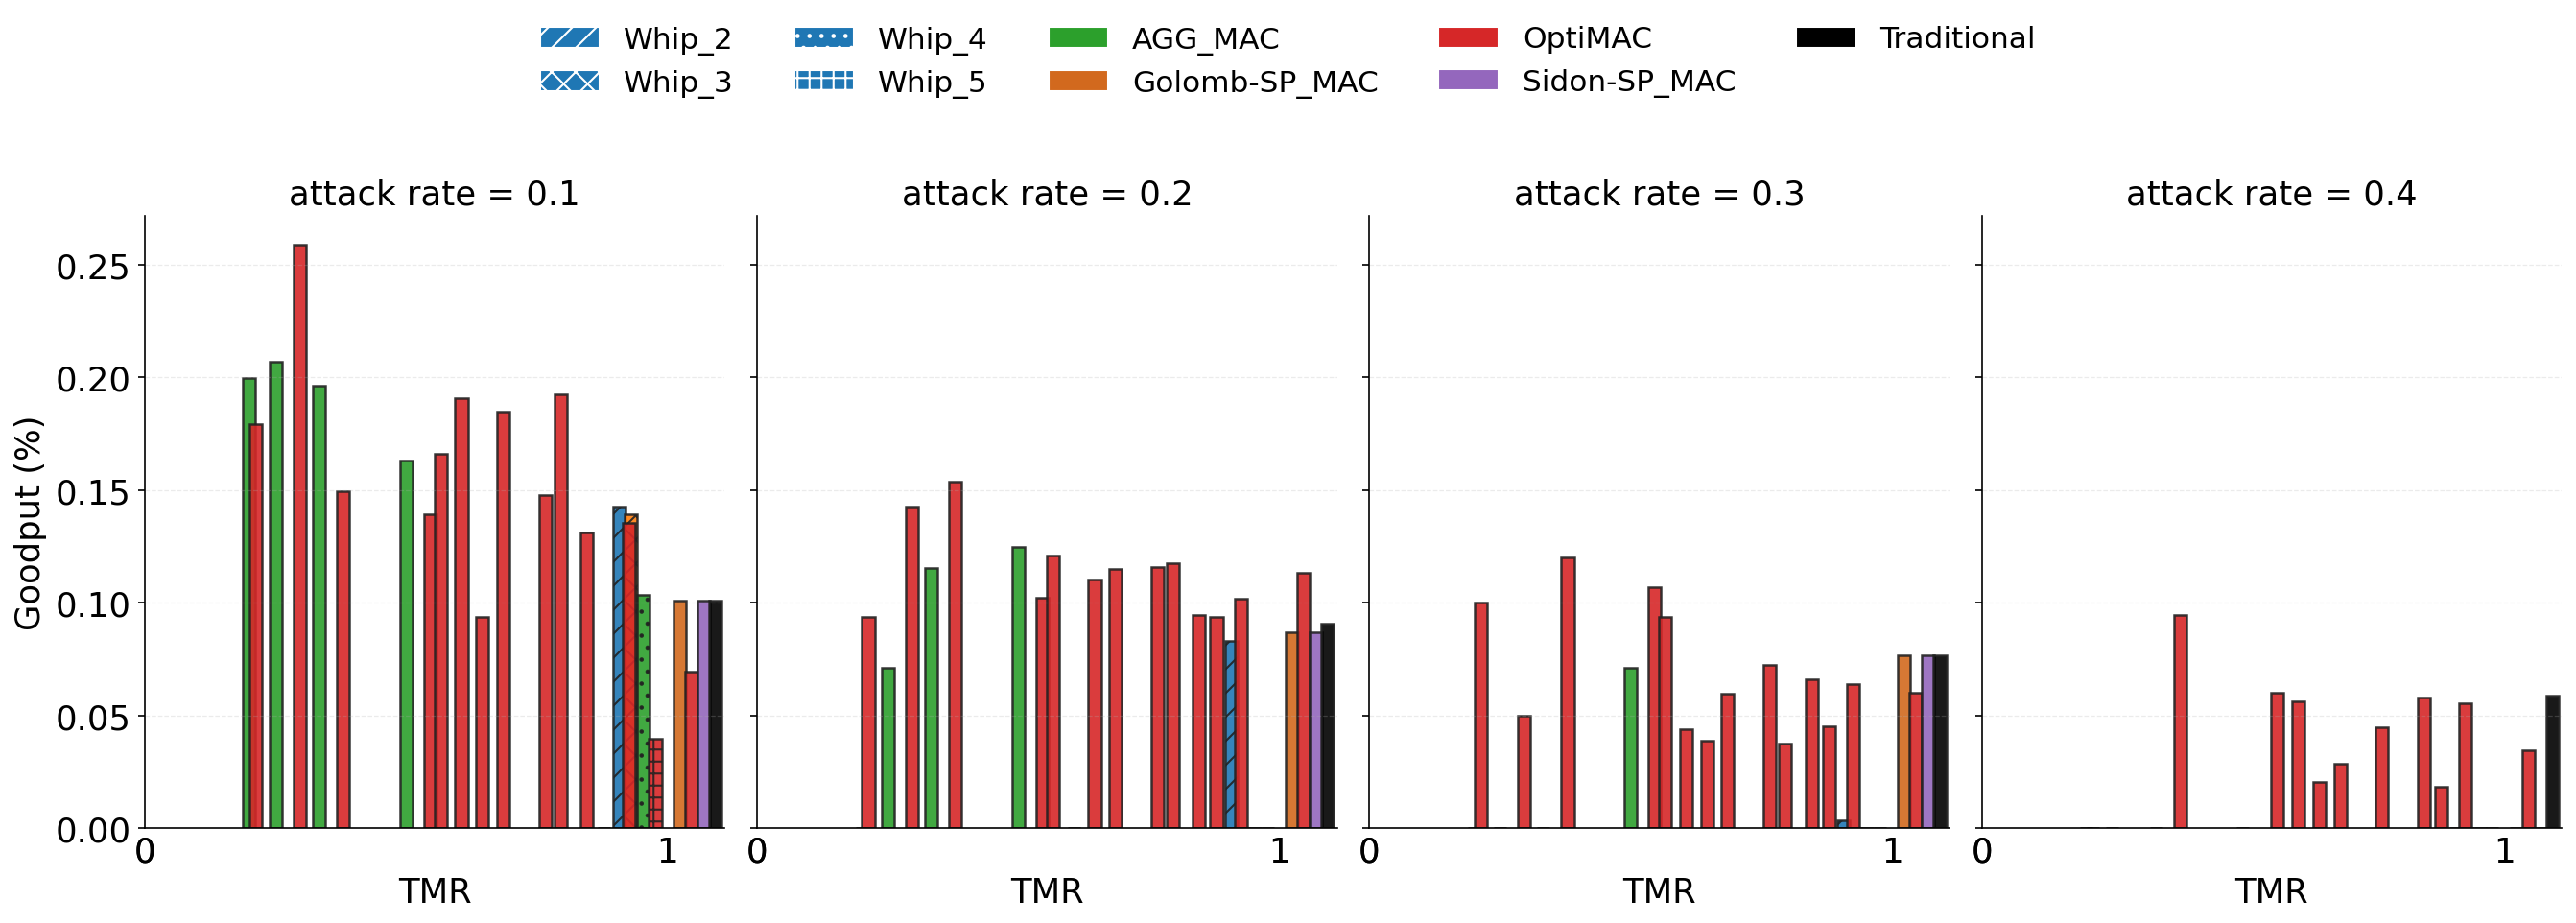

In [135]:
plot_ratio_line_subplots_beautiful(
    pd.read_csv(f'periodic_simulation_res_mSize_{32}_secReq_256.csv'),
    remove_p=(),       # or () to include 0.6 as well
    use_log_y=False,        # False for linear
    bar_width=0.024,        # try 0.05–0.08 depending on crowding
    jitter=0.023,          # separation between schemes at same ratio

    figsize_per_p=4.5,     # widen if you have many ratios
    # output_path="beautiful_side_by_side.png"
    suptitle = ""

)
